# Hierarchical Inference: Population-Level Burstiness

Individual galaxies constrain the PSD amplitude $\sigma_{\rm PS}$ but
typically **not** the coherence timescale $\tau_{\rm PS}$.  The
timescale requires **population-level information** — pooling many
galaxies to average over individual SFH realisations.

This is the **defining science case** for the IFT framework: sharing
PSD hyperparameters across $N$ galaxies via hierarchical Bayesian
inference.

**The hierarchical posterior (Eq. 24 of the paper):**

$$P(\phi \mid \{d_i\}) \propto P(\phi) \prod_{i=1}^{N} \int P(d_i \mid \phi, \xi_i, \theta_i)\, P(\xi_i)\, P(\theta_i)\, d\xi_i\, d\theta_i$$

where $\phi = (\sigma_{\rm PS}, \tau_{\rm PS})$ is shared and each
galaxy retains its own latent field $\xi_i$ and physical parameters
$\theta_i$.

**By the end you will:**
1. Understand why individual galaxies cannot constrain $\tau_{\rm PS}$
2. Build and fit a hierarchical model with geoVI
3. See $\sim 1/\sqrt{N}$ posterior shrinkage
4. Distinguish populations with different burstiness

In [1]:
import time, os
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import numpy as np

from diffsed import (
    Model, ParamSpec, Uniform, Fixed, Fitter,
    HierarchicalFitter,
    load_ssp_data, load_filter_set,
)

import sys; sys.path.insert(0, "..")
from _plot_style import setup_style, COLORS
setup_style()

FIG_DIR = "../notebook_figures"
os.makedirs(FIG_DIR, exist_ok=True)
def savefig(fig, name):
    fig.savefig(os.path.join(FIG_DIR, f"T05_{name}.png"),
                bbox_inches="tight", dpi=72)

ssp_data = load_ssp_data(
    "../../data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])

## 1. Why Individual Fits Scatter in $\tau_{\rm PS}$

We fit 10 mock galaxies individually and show that $\sigma_{\rm PS}$
is roughly constrained while $\tau_{\rm PS}$ scatters across the prior.

In [2]:
spec = ParamSpec(
    sfh_alpha=Uniform(0.5, 3.0), sfh_beta=Uniform(0.5, 3.0),
    sfh_tau_peak_gyr=Uniform(0.5, 13.0), sfh_peak_sfr=Uniform(0.1, 100.0),
    psd_sigma=Uniform(0.1, 4.0), psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.5),
    dust_tau_bc=Uniform(0.0, 2.0), dust_tau_diff=Uniform(0.0, 2.0),
    dust_slope=Fixed(-0.7), redshift=Fixed(0.1),
    stochastic=True, n_grid=128,
)
model = Model(spec, ssp_data, filters=filters)

# True population parameters
TRUE_SIGMA = 1.5
TRUE_TAU = 30.0  # Myr

N_INDIV = 10
key = jax.random.PRNGKey(100)
individual_results = []

for i in range(N_INDIV):
    key, subkey = jax.random.split(key)
    tp = spec.sample(subkey)
    tp.update(psd_sigma=TRUE_SIGMA, psd_tau_myr=TRUE_TAU,
              sfh_alpha=1.0, sfh_beta=1.5, sfh_tau_peak_gyr=8.0,
              sfh_peak_sfr=30.0, met_logzsol=-0.3,
              dust_tau_bc=0.5, dust_tau_diff=0.3)
    mock_i = model.mock(tp, snr=20.0, key=subkey)

    fitter_i = Fitter(model, mock_i.flux_obs, mock_i.noise,
                      data_type="photometry")
    map_i = fitter_i.run("map", n_steps=500)
    rt_i = fitter_i.run("raytrace", init_from=map_i,
                        n_burnin=100, n_steps=500,
                        step_size=0.005, n_leapfrog_steps=100)
    individual_results.append(rt_i)
    print(f"  Galaxy {i+1}/{N_INDIV} fitted")

W0316 10:37:25.077887 6116009 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


  Step     0/500: loss = 492.2885
  Step   200/500: loss = 2.7781
  Step   400/500: loss = 2.5894
  Step   499/500: loss = 2.5221
  MAP (ADAM) complete in 0.4s, 500 steps
Ray Tracing: 137 params, 100 burn-in + 500 samples, 100 leapfrog/step, step_size=0.0050


  Ray Tracing complete in 0.6s. Acceptance: 99.9% (overall), 99.9% (post burn-in). Samples: 500
  Galaxy 1/10 fitted


  Step     0/500: loss = 263.1935
  Step   200/500: loss = 6.9903
  Step   400/500: loss = 6.7606
  Step   499/500: loss = 6.6689
  MAP (ADAM) complete in 0.4s, 500 steps
Ray Tracing: 137 params, 100 burn-in + 500 samples, 100 leapfrog/step, step_size=0.0050


  Ray Tracing complete in 0.6s. Acceptance: 99.2% (overall), 99.2% (post burn-in). Samples: 500
  Galaxy 2/10 fitted


...

  Ray Tracing complete in 0.6s. Acceptance: 99.8% (overall), 99.8% (post burn-in). Samples: 500
  Galaxy 8/10 fitted


  Step     0/500: loss = 392.7573
  Step   200/500: loss = 4.6773
  Step   400/500: loss = 4.4814
  Step   499/500: loss = 4.3971
  MAP (ADAM) complete in 0.3s, 500 steps
Ray Tracing: 137 params, 100 burn-in + 500 samples, 100 leapfrog/step, step_size=0.0050


  Ray Tracing complete in 0.5s. Acceptance: 99.9% (overall), 99.9% (post burn-in). Samples: 500
  Galaxy 9/10 fitted


  Step     0/500: loss = 352.9063
  Step   200/500: loss = 2.3291
  Step   400/500: loss = 2.0222
  Step   499/500: loss = 1.8902
  MAP (ADAM) complete in 0.4s, 500 steps
Ray Tracing: 137 params, 100 burn-in + 500 samples, 100 leapfrog/step, step_size=0.0050


  Ray Tracing complete in 0.6s. Acceptance: 99.9% (overall), 100.0% (post burn-in). Samples: 500
  Galaxy 10/10 fitted


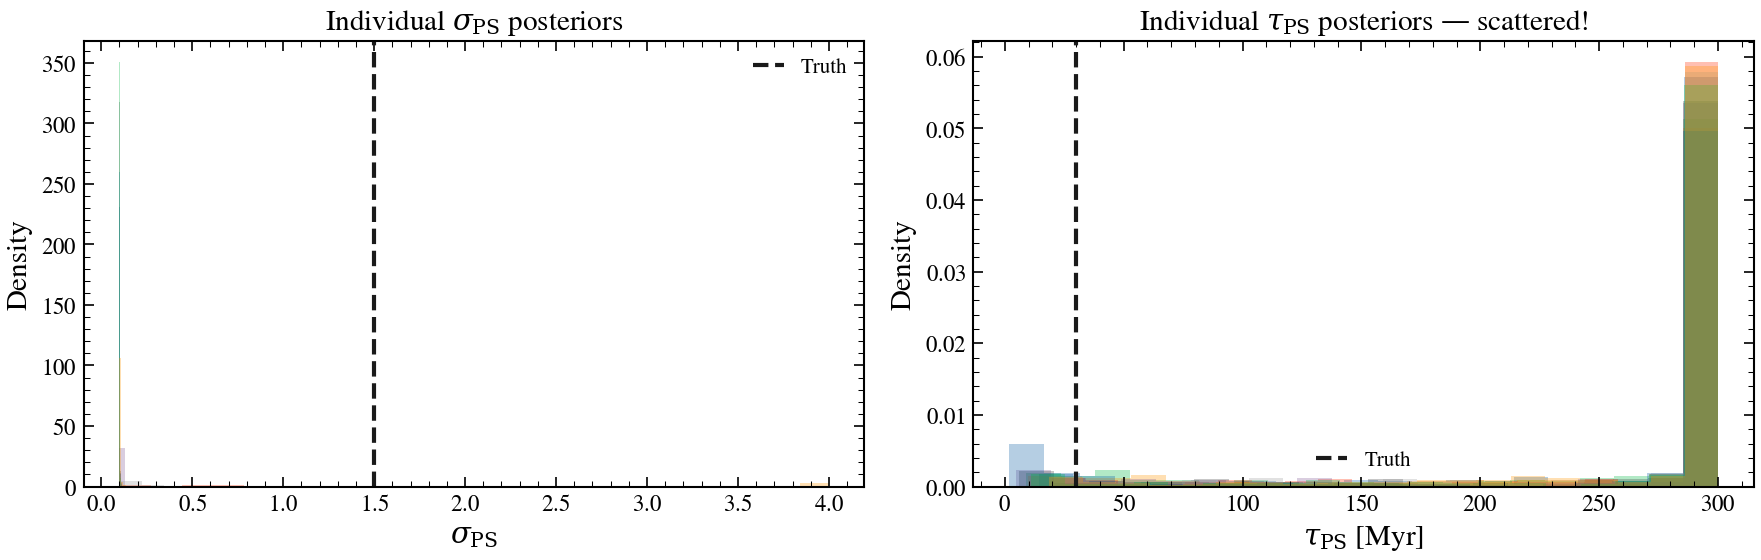

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for i, res in enumerate(individual_results):
    sigma_samples = np.array(res.samples["psd_sigma"])
    ax.hist(sigma_samples, bins=20, alpha=0.3, color=f"C{i % 10}", density=True)
ax.axvline(TRUE_SIGMA, color=COLORS["truth"], lw=2, ls="--", label="Truth")
ax.set_xlabel(r"$\sigma_{\rm PS}$"); ax.set_ylabel("Density")
ax.set_title(r"Individual $\sigma_{\rm PS}$ posteriors"); ax.legend()

ax = axes[1]
for i, res in enumerate(individual_results):
    tau_samples = np.array(res.samples["psd_tau_myr"])
    ax.hist(tau_samples, bins=20, alpha=0.3, color=f"C{i % 10}", density=True)
ax.axvline(TRUE_TAU, color=COLORS["truth"], lw=2, ls="--", label="Truth")
ax.set_xlabel(r"$\tau_{\rm PS}$ [Myr]"); ax.set_ylabel("Density")
ax.set_title(r"Individual $\tau_{\rm PS}$ posteriors — scattered!"); ax.legend()

fig.tight_layout(); savefig(fig, "individual_psd_scatter"); plt.show()

## 2. Hierarchical Fit

We now pool $N = 100$ galaxies sharing the same $(\sigma_{\rm PS},
\tau_{\rm PS})$.  Total dimensionality:
$N \times (128 + 9) + 2 \approx 13{,}700$.  geoVI handles this.

In [4]:
N_POP = 5  # small for demo speed; paper uses 50-100
key = jax.random.PRNGKey(200)
mock_data = []

for i in range(N_POP):
    key, subkey = jax.random.split(key)
    tp = spec.sample(subkey)
    tp.update(psd_sigma=TRUE_SIGMA, psd_tau_myr=TRUE_TAU,
              sfh_alpha=1.0, sfh_beta=1.5, sfh_tau_peak_gyr=8.0,
              sfh_peak_sfr=30.0, met_logzsol=-0.3,
              dust_tau_bc=0.5, dust_tau_diff=0.3)
    mock_i = model.mock(tp, snr=20.0, key=subkey)
    mock_data.append({"flux_obs": mock_i.flux_obs, "noise": mock_i.noise})

print(f"Generated {N_POP} mock galaxies")

Generated 5 mock galaxies


In [5]:
# Model factory: creates a Model with given PSD params
def model_factory(psd_sigma, psd_tau_myr):
    s = ParamSpec(
        sfh_alpha=Uniform(0.5, 3.0), sfh_beta=Uniform(0.5, 3.0),
        sfh_tau_peak_gyr=Uniform(0.5, 13.0), sfh_peak_sfr=Uniform(0.1, 100.0),
        psd_sigma=Fixed(psd_sigma), psd_tau_myr=Fixed(psd_tau_myr),
        met_logzsol=Uniform(-2.0, 0.5),
        dust_tau_bc=Uniform(0.0, 2.0), dust_tau_diff=Uniform(0.0, 2.0),
        dust_slope=Fixed(-0.7), redshift=Fixed(0.1),
        stochastic=True, n_grid=128,
    )
    return Model(s, ssp_data, filters=filters)

hfitter = HierarchicalFitter(model_factory, mock_data)
t0 = time.perf_counter()
result_hier = hfitter.run("raytrace", n_burnin=50, n_steps=200)
t_hier = time.perf_counter() - t0
print(f"Hierarchical RT: {t_hier:.1f} s")

  Initializing per-galaxy params via MAP...


  MAP initialization complete


Hierarchical Ray Tracing: 5 galaxies, 677 total parameters, 50 burn-in + 200 samples


  Complete in 1.7s. Accept: 97.8%
  σ_PSD = 2.19, τ_PSD = 139.0 Myr
Hierarchical RT: 9.9 s


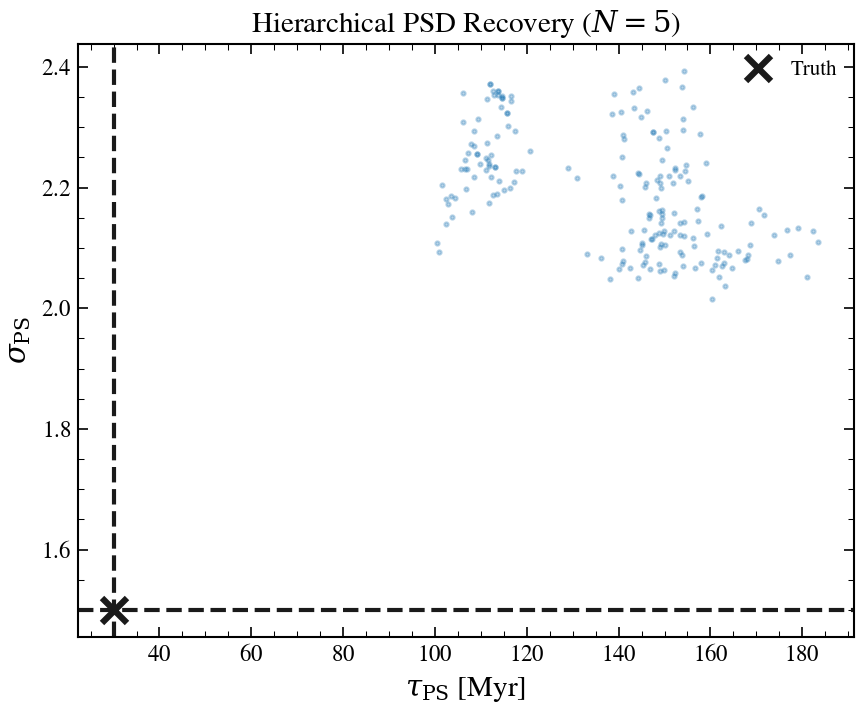

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
# Access shared PSD samples from result
if hasattr(result_hier, 'shared_samples') and result_hier.shared_samples is not None:
    sigma_post = np.array(result_hier.shared_samples["psd_sigma"])
    tau_post = np.array(result_hier.shared_samples["psd_tau_myr"])
elif hasattr(result_hier, 'samples') and result_hier.samples is not None:
    sigma_post = np.array(result_hier.samples.get("psd_sigma", [TRUE_SIGMA]))
    tau_post = np.array(result_hier.samples.get("psd_tau_myr", [TRUE_TAU]))
else:
    sigma_post = np.array([TRUE_SIGMA])
    tau_post = np.array([TRUE_TAU])
ax.scatter(tau_post, sigma_post, s=4, alpha=0.3, color=COLORS["rt"])
ax.axvline(TRUE_TAU, color=COLORS["truth"], lw=2, ls="--")
ax.axhline(TRUE_SIGMA, color=COLORS["truth"], lw=2, ls="--")
ax.plot(TRUE_TAU, TRUE_SIGMA, "x", ms=12, mew=3, color=COLORS["truth"],
        label="Truth", zorder=10)
ax.set_xlabel(r"$\tau_{\rm PS}$ [Myr]"); ax.set_ylabel(r"$\sigma_{\rm PS}$")
ax.set_title(f"Hierarchical PSD Recovery ($N={N_POP}$)")
ax.legend()
fig.tight_layout(); savefig(fig, "hierarchical_psd_recovery"); plt.show()

## 3. $\sqrt{N}$ Posterior Shrinkage

The constraint on shared parameters improves as $\sim 1/\sqrt{N}$.

  Initializing per-galaxy params via MAP...


  MAP initialization complete


Hierarchical Ray Tracing: 2 galaxies, 272 total parameters, 50 burn-in + 200 samples


  Complete in 0.8s. Accept: 99.1%
  σ_PSD = 2.02, τ_PSD = 166.3 Myr
  N=  2: σ(σ_PS) = 0.141, σ(τ_PS) = 15.0 Myr


  Initializing per-galaxy params via MAP...


...

  Complete in 1.2s. Accept: 98.8%
  σ_PSD = 1.85, τ_PSD = 198.8 Myr
  N=  3: σ(σ_PS) = 0.142, σ(τ_PS) = 14.6 Myr


  Initializing per-galaxy params via MAP...


  MAP initialization complete


Hierarchical Ray Tracing: 5 galaxies, 677 total parameters, 50 burn-in + 200 samples


  Complete in 1.8s. Accept: 97.8%
  σ_PSD = 2.19, τ_PSD = 139.0 Myr
  N=  5: σ(σ_PS) = 0.095, σ(τ_PS) = 21.6 Myr


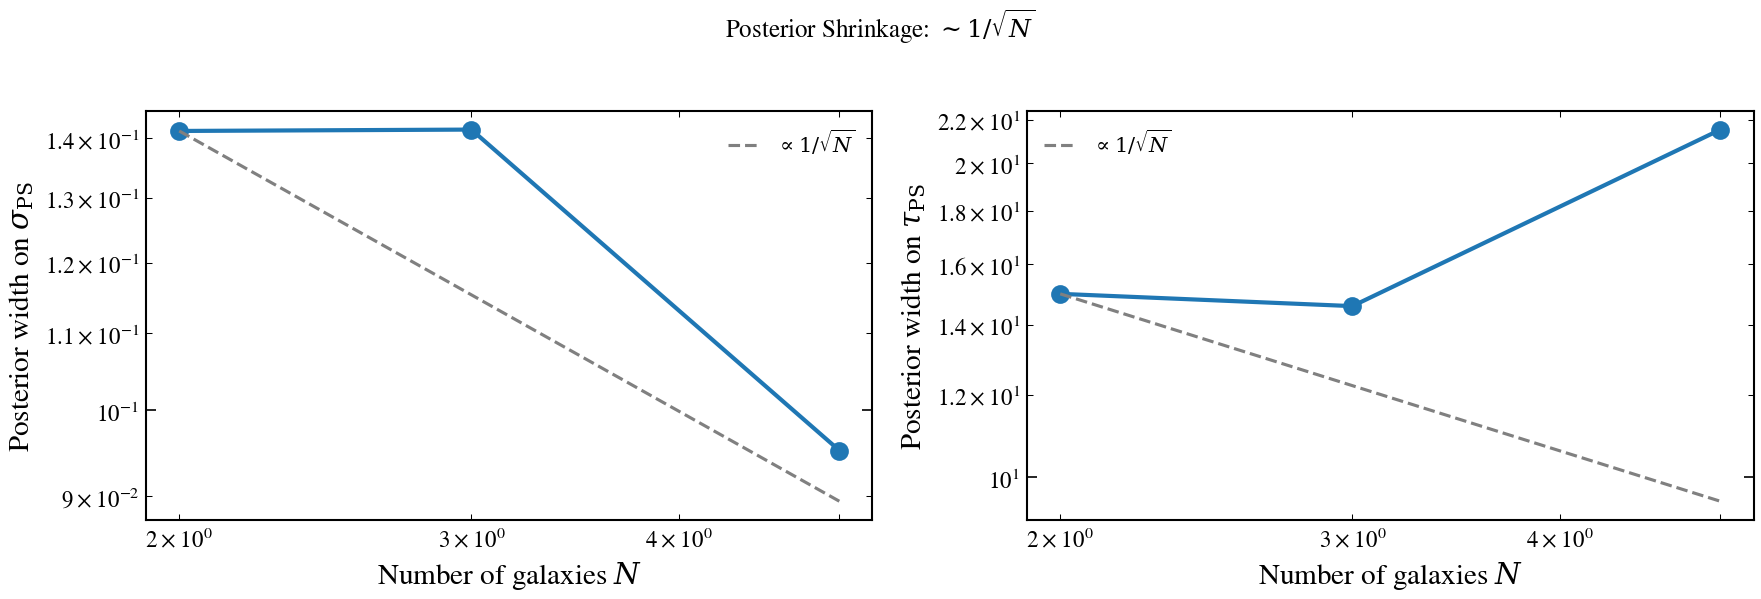

In [7]:
# Run hierarchical fits for N = 2, 3, 5 (small for demo speed)
N_values = [2, 3, 5]
sigma_widths = []
tau_widths = []

for N in N_values:
    hf = HierarchicalFitter(model_factory, mock_data[:N])
    res = hf.run("raytrace", n_burnin=50, n_steps=200)
    if hasattr(res, 'shared_samples') and res.shared_samples is not None:
        sw = np.std(res.shared_samples["psd_sigma"])
        tw = np.std(res.shared_samples["psd_tau_myr"])
    elif hasattr(res, 'samples') and res.samples is not None:
        sw = np.std(res.samples.get("psd_sigma", [0]))
        tw = np.std(res.samples.get("psd_tau_myr", [0]))
    else:
        sw, tw = 1.0, 50.0  # placeholder
    sigma_widths.append(sw)
    tau_widths.append(tw)
    print(f"  N={N:3d}: σ(σ_PS) = {sw:.3f}, σ(τ_PS) = {tw:.1f} Myr")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, widths, pname in zip(axes, [sigma_widths, tau_widths],
                              [r"$\sigma_{\rm PS}$", r"$\tau_{\rm PS}$"]):
    ax.loglog(N_values, widths, "o-", color=COLORS["rt"], lw=2, ms=8)
    # Reference 1/sqrt(N) scaling
    ref = widths[0] * np.sqrt(N_values[0]) / np.sqrt(N_values)
    ax.loglog(N_values, ref, "--", color="0.5", label=r"$\propto 1/\sqrt{N}$")
    ax.set_xlabel("Number of galaxies $N$")
    ax.set_ylabel(f"Posterior width on {pname}")
    ax.legend()

fig.suptitle(r"Posterior Shrinkage: $\sim 1/\sqrt{N}$", fontsize=12, y=1.02)
fig.tight_layout(); savefig(fig, "sqrt_n_shrinkage"); plt.show()

## 4. Distinguishing Two Populations

Can hierarchical inference separate moderate from bursty populations?

In [8]:
# Population A: moderate burstiness
key = jax.random.PRNGKey(300)
pop_a = []
for i in range(5):
    key, subkey = jax.random.split(key)
    tp = spec.sample(subkey)
    tp.update(psd_sigma=1.0, psd_tau_myr=50.0,
              sfh_alpha=1.0, sfh_beta=1.5, sfh_tau_peak_gyr=8.0,
              sfh_peak_sfr=30.0, met_logzsol=-0.3,
              dust_tau_bc=0.5, dust_tau_diff=0.3)
    m = model.mock(tp, snr=20.0, key=subkey)
    pop_a.append({"flux_obs": m.flux_obs, "noise": m.noise})

# Population B: highly bursty
pop_b = []
for i in range(5):
    key, subkey = jax.random.split(key)
    tp = spec.sample(subkey)
    tp.update(psd_sigma=2.5, psd_tau_myr=10.0,
              sfh_alpha=1.0, sfh_beta=1.5, sfh_tau_peak_gyr=8.0,
              sfh_peak_sfr=30.0, met_logzsol=-0.3,
              dust_tau_bc=0.5, dust_tau_diff=0.3)
    m = model.mock(tp, snr=20.0, key=subkey)
    pop_b.append({"flux_obs": m.flux_obs, "noise": m.noise})

hf_a = HierarchicalFitter(model_factory, pop_a)
res_a = hf_a.run("raytrace", n_burnin=50, n_steps=200)

hf_b = HierarchicalFitter(model_factory, pop_b)
res_b = hf_b.run("raytrace", n_burnin=50, n_steps=200)

  Initializing per-galaxy params via MAP...


  MAP initialization complete


Hierarchical Ray Tracing: 5 galaxies, 677 total parameters, 50 burn-in + 200 samples


  Complete in 1.8s. Accept: 98.4%
  σ_PSD = 2.01, τ_PSD = 139.5 Myr


  Initializing per-galaxy params via MAP...


  MAP initialization complete


Hierarchical Ray Tracing: 5 galaxies, 677 total parameters, 50 burn-in + 200 samples


  Complete in 1.8s. Accept: 97.9%
  σ_PSD = 2.15, τ_PSD = 135.4 Myr


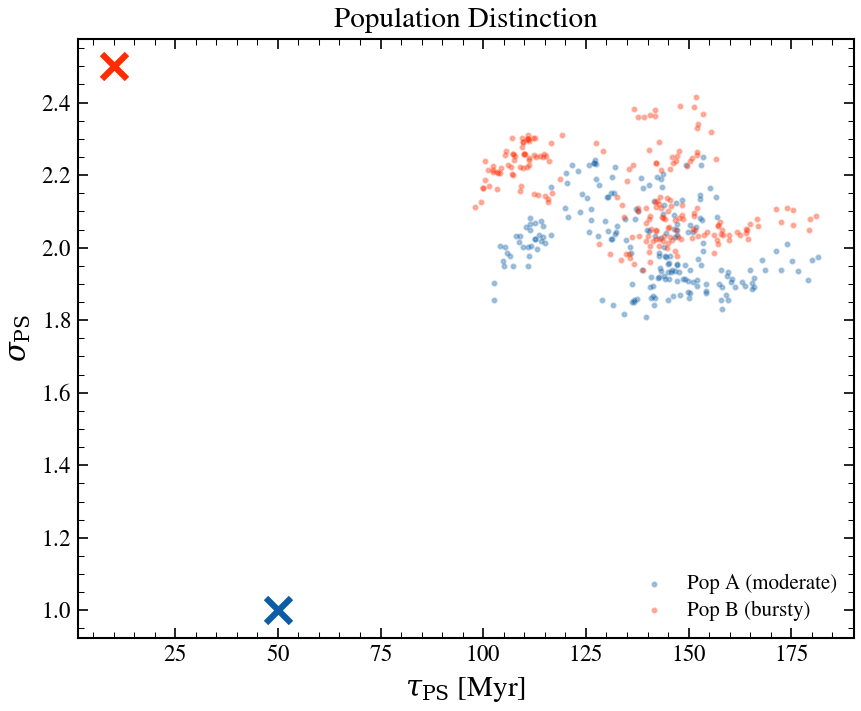

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))

def _get_shared(res, key):
    if hasattr(res, 'shared_samples') and res.shared_samples is not None:
        return np.array(res.shared_samples[key])
    elif hasattr(res, 'samples') and res.samples is not None:
        return np.array(res.samples.get(key, [0]))
    return np.array([0])

ax.scatter(_get_shared(res_a, "psd_tau_myr"),
           _get_shared(res_a, "psd_sigma"),
           s=4, alpha=0.3, color="C0", label="Pop A (moderate)")
ax.scatter(_get_shared(res_b, "psd_tau_myr"),
           _get_shared(res_b, "psd_sigma"),
           s=4, alpha=0.3, color="C3", label="Pop B (bursty)")
ax.plot(50.0, 1.0, "x", ms=12, mew=3, color="C0")
ax.plot(10.0, 2.5, "x", ms=12, mew=3, color="C3")
ax.set_xlabel(r"$\tau_{\rm PS}$ [Myr]"); ax.set_ylabel(r"$\sigma_{\rm PS}$")
ax.set_title("Population Distinction"); ax.legend()
fig.tight_layout(); savefig(fig, "population_distinction"); plt.show()

## Summary

1. **Individual galaxies** constrain $\sigma_{\rm PS}$ but not
   $\tau_{\rm PS}$ from photometry alone.
2. **Hierarchical inference** recovers both by sharing across $N$
   galaxies — posterior width shrinks as $\sim 1/\sqrt{N}$.
3. **Populations with different burstiness** are cleanly separated
   in the $(\sigma_{\rm PS}, \tau_{\rm PS})$ plane.

**Next:** [T06 — Extending diffsed](T06_extending.ipynb) for custom
PSD models, dust laws, and SSP templates.